<a href="https://colab.research.google.com/github/Atul245/Computer_vision-mnit/blob/main/Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOG-based Pedestrian Detection

[INFO] Loading local image: /content/hogi.jpg
[INFO] Initializing HOG + SVM people detector...
[INFO] Scanning image for pedestrians (this might take a moment)...
[INFO] Found 15 initial overlapping detections.
[INFO] Confirmed 12 pedestrians after suppression.


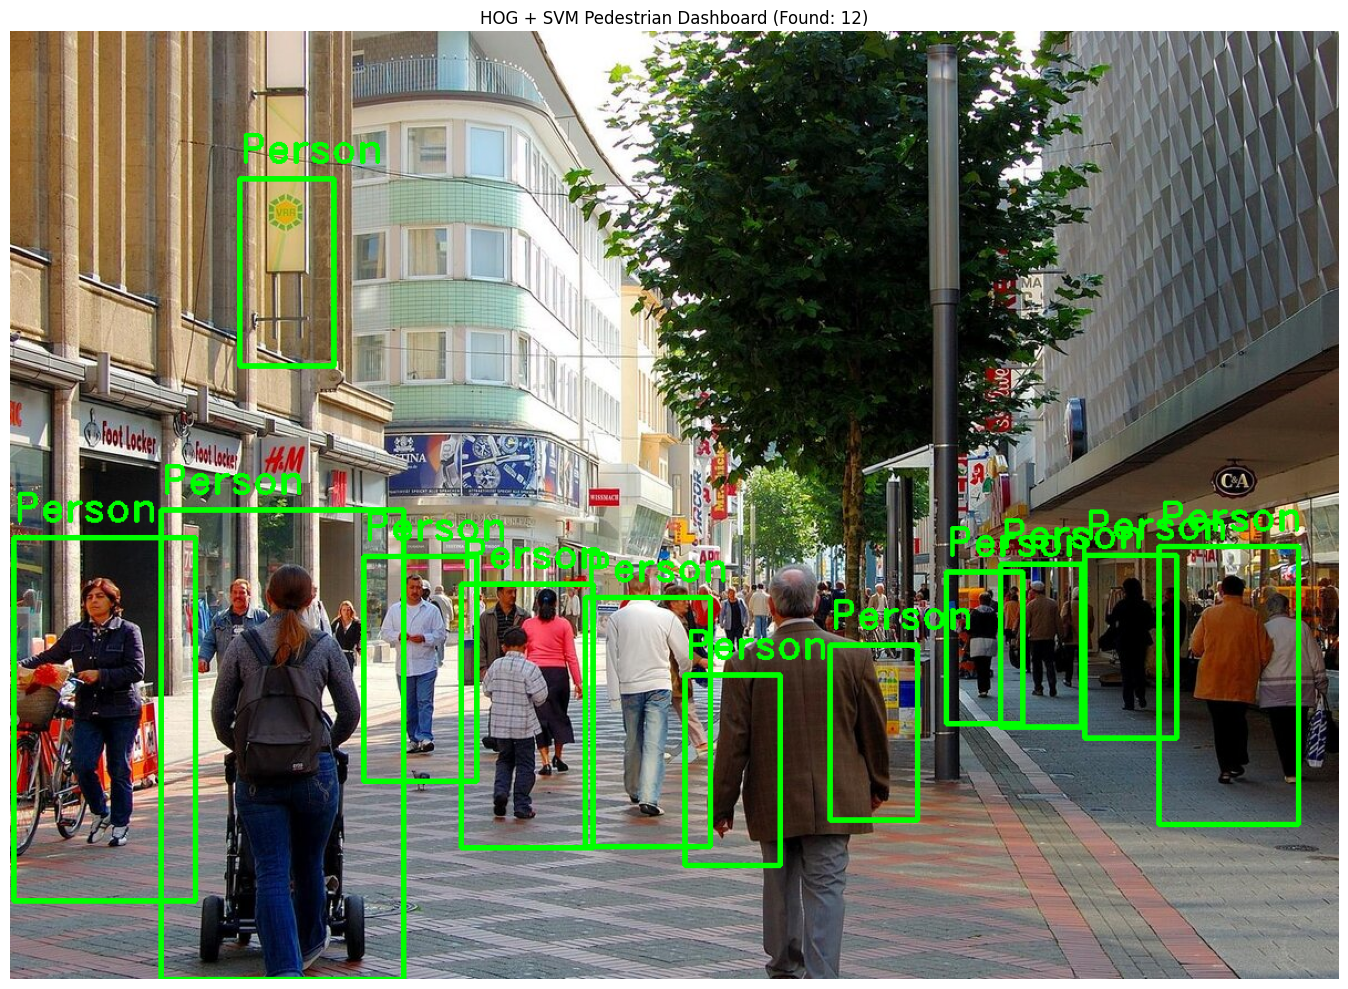

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression
import requests
from io import BytesIO

def detect_pedestrians_static(image_source, use_url=False):
    """
    Runs high-accuracy pedestrian detection on a single static image.
    """

    if use_url:
        print(f"[INFO] Downloading image from: {image_source}")
        try:
            response = requests.get(image_source)
            image_bytes = BytesIO(response.content)
            image = cv2.imdecode(np.frombuffer(image_bytes.read(), np.uint8), cv2.IMREAD_COLOR)
        except Exception as e:
            print(f"[ERROR] Could not download image: {e}")
            return
    else:
        print(f"[INFO] Loading local image: {image_source}")
        image = cv2.imread(image_source)

    if image is None:
        print("[ERROR] Could not load image. Check path/URL.")
        return


    orig = image.copy()
    output_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    print("[INFO] Initializing HOG + SVM people detector...")
    hog = cv2.HOGDescriptor() #
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector()) #


    print("[INFO] Scanning image for pedestrians (this might take a moment)...")
    (rects, weights) = hog.detectMultiScale(
        image,
        winStride=(4, 4), # Tighter scan
        padding=(8, 8),   #
        scale=1.05        # Smaller steps between scales for higher recall
    )


    print(f"[INFO] Found {len(rects)} initial overlapping detections.")

    if len(rects) > 0:

        rects_array = np.array([[x, y, x + w, y + h] for (x, y, w, h) in rects])


        pick = non_max_suppression(rects_array, probs=None, overlapThresh=0.5)
        print(f"[INFO] Confirmed {len(pick)} pedestrians after suppression.")


        for (xA, yA, xB, yB) in pick:

            cv2.rectangle(output_img, (xA, yA), (xB, yB), (0, 255, 0), 3)


            cv2.putText(output_img, "Person", (xA, yA - 15),
                        cv2.FONT_HERSHEY_DUPLEX, 1.2, (0, 255, 0), 2)
    else:
        print("[INFO] No pedestrians detected in the image.")


    plt.figure(figsize=(15, 10))
    plt.imshow(output_img)
    plt.title(f"HOG + SVM Pedestrian Dashboard (Found: {len(pick)})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

local_image_path = "/content/hogi.jpg"
detect_pedestrians_static(local_image_path, use_url=False)

In [ ]:
!pip install imutils

In [ ]:
import cv2
import numpy as np
from base64 import b64decode
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression

def camera_capture_and_detect():

    js = """
    async function captureAndReturn() {

      const div = document.createElement('div');

      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Capture & Detect';
      button.style.fontSize = '20px';
      button.style.marginTop = '10px';

      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);

      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video:true});

      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    """

    data = eval_js(js + "captureAndReturn()")

    binary = b64decode(data.split(',')[1])

    with open("capture.jpg","wb") as f:
        f.write(binary)

    return "capture.jpg"


# Step 1: Capture image
image_path = camera_capture_and_detect()

# Step 2: Pedestrian detection
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

image = cv2.imread(image_path)
image = cv2.resize(image,(640,480))

rects, weights = hog.detectMultiScale(
    image,
    winStride=(4,4),
    padding=(8,8),
    scale=1.05
)

rects = np.array([[x,y,x+w,y+h] for (x,y,w,h) in rects])

pick = non_max_suppression(rects, overlapThresh=0.65)

for (xA,yA,xB,yB) in pick:
    cv2.rectangle(image,(xA,yA),(xB,yB),(0,255,0),2)
    cv2.putText(image,"Pedestrian",(xA,yA-5),
                cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

cv2.putText(image,f"People detected: {len(pick)}",
            (20,40),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)

cv2_imshow(image)